In [1]:
#This file creates some of the main figures from the paper (FIGURES XXXX)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from datetime import datetime
from matplotlib.ticker import FuncFormatter
from scipy import stats
from scipy.interpolate import interp1d

MAIN TEXT FIGURES

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 2500)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/default_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.19, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/default_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE E.4.B
# Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/default_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE E.4.a 
#Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'GPT-4.5'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 7:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

ax.text(model_effects_x, 40, 
        "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
        ha='center', va='top', fontsize=12, 
        bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: GPT-4.5 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/default_figs/top_models_individual_bars.pdf')
plt.show()

MATH: 785 Models

In [ ]:
#APPENDIX FIGURE D.3.c

plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 50000)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)
# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/math_figs/compute_factors_companies_math.pdf')
plt.show()



In [ ]:
#Figure D.3.e
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/data_for_python_graphs.dta')

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    print(len(filtered_data))
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    ax.set_xlim(-3.5, 1.5)  # Adjust these values to control spread

    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.25, f'{spread_p10_p90:.2f}x', fontsize=15, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(0.03, 0.41, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 5)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/math_figs/kdensity_math.pdf')
plt.show()

In [ ]:
#FIGURE 3A: Top Model Decomposition

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'GPT-4-Turbo'].iloc[0]
model2 = df[df['model_id'] == 'Grok3-Beta'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 6:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

#ax.text(model_effects_x, 40, 
 #       "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
  #      ha='center', va='top', fontsize=12, 
   #     bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: GPT 4 Turbo (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Grok 3 Beta (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90%'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/math_figs/top_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE 3B
# Graph of Meek Models with individual bars and difference indicators

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == "Qwen__Qwen1.5-14B-Chat"].iloc[0]
model2 = df[df['model_id'] == "microsoft__Phi-3.5-mini-instruct"].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 6:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Qwen 1.5 14B ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Phi 3.5 Mini ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/math/math_figs/meek_models_individual_bars.pdf')
plt.show()

NO LIFE ARCH: 793 Models

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/no_lifearch_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/no_lifearch_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE 3B
# Graph of Meek Models with individual bars and difference indicators

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/no_lifearch_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE 3A: Top Model Decomposition

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'Deepseek-V3'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 6:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

#ax.text(model_effects_x, 40, 
 #       "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
  #      ha='center', va='top', fontsize=12, 
   #     bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Deepseek V3 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90%'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/no_lifearch/no_lifearch_figs/top_models_individual_bars.pdf')
plt.show()

WITH HUGGING FACE MODELS: 789 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/huggingface/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 2500)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI']
ax.set_yticks(range(1, 8))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/huggingface/huggingface_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/huggingface/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/huggingface/huggingface_figs/kdensity_mmlu.pdf')
plt.show()

MoE Control: 804 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 2500)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI']
ax.set_yticks(range(1, 8))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/moe_figs/compute_factors_companies.pdf')
plt.show()

Sample size: 117
Bandwidth used: 0.255601 (from Stata)
Percentiles - P10: -0.6421, P25: -0.0993, P75: 0.3428, P90: 0.6022


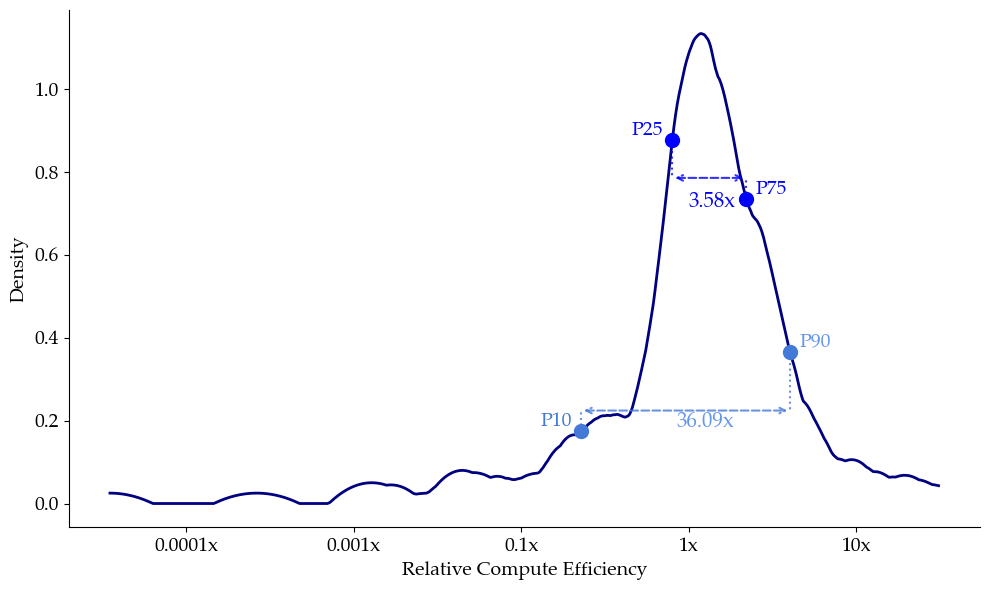

In [2]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/moe_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE 3B
# Graph of Meek Models with individual bars and difference indicators

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'MoE': model1['moe_effect'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'MoE': model2['moe_effect'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(17, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'MoE', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], max(pct1, 0) + 1.5,
                '0%',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7,
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2

        # If bar is too small (less than ~3% height), place label below
        if bar_height < 3:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y,
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y,
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/moe_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE 3A: Top Model Decomposition

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'Deepseek-V3'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'MoE': model1['moe_effect'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'MoE': model2['moe_effect'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(17, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'MoE', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 6:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

#ax.text(model_effects_x, 40, 
 #       "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
  #      ha='center', va='top', fontsize=12, 
   #     bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Deepseek V3 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90%'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/moe/moe_figs/top_models_individual_bars.pdf')
plt.show()

WITH REASONING MODELS: 819 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 2500)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/reasoning_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.70, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/reasoning_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE 3B
# Graph of Meek Models with individual bars and difference indicators

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/reasoning_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE 3A: Top Model Decomposition

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'GPT-o1'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 6:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

#ax.text(model_effects_x, 40, 
 #       "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
  #      ha='center', va='top', fontsize=12, 
   #     bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: GPT-o1 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90%'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/reasoning/reasoning_figs/top_models_individual_bars.pdf')
plt.show()

TOTAL TOKEN COUNT MODELS: 255 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 20000)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/total_token_count_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE 2E: Kdensity for MMLU PRO 
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.15, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.15, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.15, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.15, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.17, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.14, 0.65, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 2)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#

plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/total_token_count_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE 3B
# Graph of Meek Models with individual bars and difference indicators

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/total_token_count_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE 3A: Top Model Decomposition

plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'GPT-4.5'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], max(pct1, 0) + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 7:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], max(pct2, 0) + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

ax.text(model_effects_x, 40, 
        "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
        ha='center', va='top', fontsize=12, 
        bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: GPT-4.5 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90%'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/total_token_count/total_token_count_figs/top_models_individual_bars.pdf')
plt.show()

ASYMMETRIC LOGIT 0.7: 809 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 10000)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/asym07_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE E.3.e 
#KDENSITY GRAPH FOR ASYM 07
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    ax.set_xlim(-4.5, 1.5) 
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.17, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.17, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.17, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.17, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.13, 0.16, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.20, 0.40, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=15)
    ax.set_ylabel('Density', fontsize=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 15)
    ax.tick_params(axis='y', labelsize=15)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 3)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/asym07_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE E.4.B
# Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/asym07_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE E.4.a 
#Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'GPT-4.5'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 7:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

ax.text(model_effects_x, 40, 
        "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
        ha='center', va='top', fontsize=12, 
        bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: GPT-4.5 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym07/asym07_figs/top_models_individual_bars.pdf')
plt.show()

ASYMMETRIC LOGIT 1.2: 809 Models

In [ ]:
#FIGURE 2C: MMLU Company Compute Factors
plt.rcParams['font.family'] = 'Palatino Linotype'

# Read your Stata data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/data_for_python_graphs.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Plot individual models with color gradient
scatter = ax.scatter(df['comp_and_res_flop_factor'], df['ypos'], 
                     c=df['log_flops'], cmap=cmap, s=40, alpha=0.8, 
                     edgecolors='none', label='Company Secret Sauce + Model Effect')

# Build per-company CI for the company FE factor.
# Prefer pre-saved bounds if present; otherwise compute from comp_fe ± 1.645*comp_fe_se.
beta = df['beta_log_flops'].iloc[0]
baseline = df['baseline_other_FE']

if True:
    fe_a = df['comp_fe'] - 1.96 * df['comp_fe_se']
    fe_b = df['comp_fe'] + 1.96 * df['comp_fe_se']
    df['_factor_lo_raw'] = np.exp((np.minimum(fe_a, fe_b) - baseline) / beta)
    df['_factor_hi_raw'] = np.exp((np.maximum(fe_a, fe_b) - baseline) / beta)

company_data = df.groupby('ypos').agg(
    Company_fe_flop_factor=('Company_fe_flop_factor', 'first'),
    factor_lo=('_factor_lo_raw', 'first'),
    factor_hi=('_factor_hi_raw', 'first'),
).reset_index()

# Asymmetric error bars (distances from the point)
x_center = company_data['Company_fe_flop_factor'].values
xerr_low = np.clip(x_center - company_data['factor_lo'].values, 0, None)
xerr_high = np.clip(company_data['factor_hi'].values - x_center, 0, None)

ax.errorbar(x_center, company_data['ypos'],
            xerr=[xerr_low, xerr_high],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=4, zorder=4)

# Plot company fixed effects as black triangles
ax.scatter(x_center, company_data['ypos'], 
           marker='^', s=100, c='black', label='Company Secret Sauce', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 5000)
ax.tick_params(axis='x', labelsize=13)


# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek', 
             'Meta', 'Google', '01-AI', 'Anthropic', 
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize = 16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Model Size (Log FLOPs)', fontsize=14)


# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)
cbar.ax.tick_params(labelsize=13)
# Add legend
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('compute_factor_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/asym12_figs/compute_factors_companies.pdf')
plt.show()

In [ ]:
#FIGURE E.7.e

#KDENSITY GRAPH FOR ASYM 07

df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/data_for_python_graphs.dta')

plt.rcParams['font.family'] = ['Palatino Linotype']

def create_density_plot(df, beta_log_flops, stata_bandwidth=None):
    """
    Create a kernel density plot with percentile markers similar to Stata output.
    
    Parameters:
    df: DataFrame with columns 'omega' and 'top_ten_comp'
    beta_log_flops: Regression coefficient from log_flops (scalar value)
    stata_bandwidth: Optional - use exact bandwidth from Stata for perfect matching
    """
    
    # Filter data (excluding top_ten_comp values 13, 14, 15)
    filtered_data = df[(df['top_ten_comp'] != 'Other, Med') & 
                   (df['top_ten_comp'] != 'Other, Small') & 
                   (df['top_ten_comp'] != 'Other, Large')]['omega'].dropna()
    
    # Calculate percentiles (NumPy's default linear interpolation matches Stata)
    p10 = np.percentile(filtered_data, 10)
    p25 = np.percentile(filtered_data, 25)
    p75 = np.percentile(filtered_data, 75)
    p90 = np.percentile(filtered_data, 90)
    
    # Perform kernel density estimation using Epanechnikov kernel (Stata's default)
    # Stata uses Epanechnikov kernel, not Gaussian
    n = len(filtered_data)
    sd = np.std(filtered_data, ddof=1)
    iqr = np.percentile(filtered_data, 75) - np.percentile(filtered_data, 25)
    
    # Silverman's rule of thumb for Epanechnikov (Stata's default)
    bw_silverman = 0.9 * min(sd, iqr / 1.34) * (n ** (-0.2))
    
    # Use Stata's bandwidth if provided, otherwise use Silverman's rule
    bandwidth = stata_bandwidth if stata_bandwidth is not None else bw_silverman
    
    # Use statsmodels for Epanechnikov kernel (matches Stata)
    from statsmodels.nonparametric.kde import KDEUnivariate
    
    kde_model = KDEUnivariate(filtered_data)
    kde_model.fit(kernel='epa', bw=bandwidth, fft=False, gridsize=1000, cut=0)
    
    x_dens = kde_model.support
    dens_val = kde_model.density
    
    print(f"Sample size: {n}")
    print(f"Bandwidth used: {bandwidth:.6f} {'(from Stata)' if stata_bandwidth else '(Silverman)'}")
    print(f"Percentiles - P10: {p10:.4f}, P25: {p25:.4f}, P75: {p75:.4f}, P90: {p90:.4f}")
    
    # Find density values at each percentile
    def get_density_at_percentile(x_dens, dens_val, percentile_value):
        idx = np.argmin(np.abs(x_dens - percentile_value))
        return x_dens[idx], dens_val[idx]
    
    x_p10, dens_p10 = get_density_at_percentile(x_dens, dens_val, p10)
    x_p25, dens_p25 = get_density_at_percentile(x_dens, dens_val, p25)
    x_p75, dens_p75 = get_density_at_percentile(x_dens, dens_val, p75)
    x_p90, dens_p90 = get_density_at_percentile(x_dens, dens_val, p90)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot kernel density
    ax.plot(x_dens, dens_val, color='#000080', linewidth=2, label='Density')
    ax.set_xlim(-5.5, 2) 
    
    # Plot percentile markers
    ax.scatter([x_p10, x_p90], [dens_p10, dens_p90], 
               color="#4579D7", s=100, zorder=5, marker='o')
    ax.scatter([x_p25, x_p75], [dens_p25, dens_p75], 
               color='#0000FF', s=100, zorder=5, marker='o')
    
    # Helper function to draw horizontal arrows with vertical connectors
    def draw_horizontal_percentile_connection(x1, y1, x2, y2, color, alpha=0.8):
        # Draw vertical line from lower point up to the horizontal line level
        vertical_offset = 0.05  # Small offset above the lower point
        y_line = min(y1, y2) + vertical_offset
        
        # Draw short vertical line from p10 point
        ax.plot([x1, x1], [y1, y_line], 
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw short vertical line to p90 point  
        ax.plot([x2, x2], [y2, y_line],
                color=color, linestyle=':', linewidth=1.5, alpha=alpha)
        
        # Draw horizontal dashed line with arrows
        ax.annotate('', xy=(x2, y_line), xytext=(x1, y_line),
                   arrowprops=dict(arrowstyle='<->', color=color, lw=1.5, 
                                 alpha=alpha, linestyle='--'))
    
    # Draw connections for P10-P90
    draw_horizontal_percentile_connection(x_p10, dens_p10, x_p90, dens_p90, "#4579D7")
    
    # Draw connections for P25-P75
    draw_horizontal_percentile_connection(x_p25, dens_p25, x_p75, dens_p75, '#0000FF')
    
    # Add text labels for percentiles
    ax.text(x_p10 - 0.17, dens_p10, 'P10', fontsize=14, color="#4579D7", 
            ha='center', va='bottom')
    ax.text(x_p25 - 0.17, dens_p25, 'P25', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p75 + 0.17, dens_p75, 'P75', fontsize=14, color='#0000FF', 
            ha='center', va='bottom')
    ax.text(x_p90 + 0.17, dens_p90, 'P90', fontsize=14, color='#6495ED', 
            ha='center', va='bottom')
    
    flop_p10 = np.exp(p10 / beta_log_flops)
    flop_p25 = np.exp(p25 / beta_log_flops)
    flop_p75 = np.exp(p75 / beta_log_flops)
    flop_p90 = np.exp(p90 / beta_log_flops)
    
    spread_p10_p90 = flop_p90 / flop_p10
    spread_p25_p75 = flop_p75 / flop_p25
    
    ax.text(0.1, 0.15, f'{spread_p10_p90:.2f}x', fontsize=15, color='#6495ED', 
            ha='center', va='bottom')
    ax.text(0.15, 0.28, f'{spread_p25_p75:.2f}x', fontsize=15, color='#0000FF', 
            ha='center', va='bottom')
    
    # Set x-axis labels (assuming log scale for compute factor)
    ax.set_xlabel('Relative Compute Efficiency', fontsize=15)
    ax.set_ylabel('Density', fontsize=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Custom x-tick labels
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xticklabels(['0.0001x', '0.001x', '0.1x', '1x', '10x'], fontsize = 15)
    ax.tick_params(axis='y', labelsize=15)
    
    plt.tight_layout()
    return fig, ax

# Example usage:
# First, get your regression coefficient (e.g., from statsmodels)
# from your regression: beta_log_flops = results.params['log_flops']
# Or if you have it stored: beta_log_flops = 0.5  # example value
beta_log_flops = df['beta_log_flops'].iloc[0]
# For exact match with Stata, use the bandwidth from Stata's output
fig, ax = create_density_plot(df, beta_log_flops, stata_bandwidth=0.1278006589358956 * 3)
#
# Or let it calculate bandwidth automatically:
# fig, ax = create_density_plot(df, beta_log_flops)
#
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/asym12_figs/kdensity_mmlu.pdf')
plt.show()

In [ ]:
#FIGURE E.4.B
# Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'google__flan-ul2'].iloc[0]
model2 = df[df['model_id'] == 'nvidia__Minitron-4B-Base'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2

    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) == 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 0.5, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1, 
                '0%',
                ha='center', va='center', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

    ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
        bottom=bottom_pos, color=diff_color, alpha=0.7, 
        edgecolor='white', linewidth=1)

    # Text in the middle of the difference bar (or below if too small)
    text_y = bottom_pos + bar_height/2
    
    # If bar is too small (less than ~3% height), place label below
    if bar_height < 3:
        text_y = bottom_pos - 1  # Position below the bar
        text_color = 'black'
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow} {abs(pct_diff):.1f}%',
                ha='center', va='top', fontsize=14, weight='bold', color=text_color)
    else:
        ax.text(x_positions[bar_index + 1], text_y, 
                f'{arrow}\n{abs(pct_diff):.1f}%',
                ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -2, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Google Flan UL2 ({model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: Nvidia Minitron 4B ({model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'])
ax.tick_params(axis='y', labelsize=12)

# Styling
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-5, 75)
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/asym12_figs/meek_models_individual_bars.pdf')
plt.show()

In [ ]:
#FIGURE E.4.a 
#Graph of Meek Models with individual bars and difference indicators

# Set font to Palatino with fallback for Unicode
plt.rcParams['font.family'] = ['Palatino Linotype', 'DejaVu Sans']

# Read your data
df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/data_for_python_graphs.dta')

# Get the two models
model1 = df[df['model_id'] == 'meta-llama__Llama-2-70b-hf'].iloc[0]
model2 = df[df['model_id'] == 'GPT-4.5'].iloc[0]

# Components for each model - rescale to match MMLU Pro scores
raw_components1 = {
    'Scaling': model1['scaling'],
    'Shared Progress': model1['spillover'],
    'Company Secret Sauce': model1['comp_fe'],
    'Model Residual Efficiency': model1['omega']
}

raw_components2 = {
    'Scaling': model2['scaling'],
    'Shared Progress': model2['spillover'],
    'Company Secret Sauce': model2['comp_fe'],
    'Model Residual Efficiency': model2['omega']
}

# Rescale components to match MMLU Pro scores
raw_total1 = sum(raw_components1.values())
raw_total2 = sum(raw_components2.values())

scale1 = model1['acc_norm_new'] / raw_total1
scale2 = model2['acc_norm_new'] / raw_total2

components1 = {k: v * scale1 for k, v in raw_components1.items()}
components2 = {k: v * scale2 for k, v in raw_components2.items()}

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Colors
colors = {
    'Scaling': '#00008B',
    'Shared Progress': '#6495ED',
    'Company Effects': '#ADD8E6',
    'Model Residual Efficiency': '#808080'
}

# Ordered components
ordered_components = ['Scaling', 'Shared Progress', 'Company Secret Sauce', 'Model Residual Efficiency']

# Bar positioning - 3 bars per component (model1, difference, model2)
bar_width = 0.6
group_spacing = 0.05
diff_width = 0.6

# Calculate positions for each group of 3 bars
x_positions = []
current_x = 0
for i in range(len(ordered_components)):
    # Model 1 bar
    x_positions.append(current_x)
    # Difference bar (smaller, centered)
    x_positions.append(current_x + bar_width + group_spacing)
    # Model 2 bar
    x_positions.append(current_x + bar_width + group_spacing + diff_width + group_spacing)
    # Move to next group
    current_x = x_positions[-1] + bar_width + 0.4

# Calculate totals for percentages
total1 = sum(components1.values())
total2 = sum(components2.values())

# Plot bars for each component
bar_index = 0
model1_color = "#96979B"  # Blue for model 1
model2_color = "#4B5053"  # Orange for model 2

for component in ordered_components:
    val1 = components1[component]
    val2 = components2[component]
    
    # Calculate percentage contributions
    pct1 = (val1 / total1) * 100
    pct2 = (val2 / total2) * 100
    pct_diff = pct2 - pct1

    display_pct1 = 1 if pct1 == 0 else pct1
    display_pct2 = 1 if pct2 == 0 else pct2
    
    # Model 1 bar (percentage)
    ax.bar(x_positions[bar_index], display_pct1, bar_width,
           color=model1_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index], pct1 + 0.5, f'{pct1:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # After calculating pct_diff, add this check:
    if abs(pct_diff) < 0.01:  # No change (adjust threshold as needed)
        # Plot a thin line or very small bar at the baseline
        ax.bar(x_positions[bar_index + 1], 2, diff_width,
            bottom=pct1, color='gray', alpha=0.5, 
            edgecolor='white', linewidth=1)
        ax.text(x_positions[bar_index + 1], pct1 + 2.5, 
                '0pp',
                ha='center', va='bottom', fontsize=12, weight='bold', color='black')
    else:
        # Difference bar - positioned to show the actual change
        if pct_diff < 0:  # Decrease
            # Bar goes from pct2 to pct1 (showing the decrease)
            diff_color = 'red'
            arrow = '↓'
            bottom_pos = pct2
            bar_height = abs(pct_diff)
        else:  # Increase
            # Bar goes from pct1 to pct2 (showing the increase)
            diff_color = 'blue'
            arrow = '↑'
            bottom_pos = pct1
            bar_height = abs(pct_diff)

        ax.bar(x_positions[bar_index + 1], bar_height, diff_width,
            bottom=bottom_pos, color=diff_color, alpha=0.7, 
            edgecolor='white', linewidth=1)

        # Text in the middle of the difference bar (or below if too small)
        text_y = bottom_pos + bar_height/2
        
        # If bar is too small (less than ~3% height), place label below
        if bar_height < 7:
            text_y = bottom_pos - 1  # Position below the bar
            text_color = 'black'
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow} {abs(pct_diff):.1f}%',
                    ha='center', va='top', fontsize=14, weight='bold', color=text_color)
        else:
            ax.text(x_positions[bar_index + 1], text_y, 
                    f'{arrow}\n{abs(pct_diff):.1f}%',
                    ha='center', va='center', fontsize=14, weight='bold', color='white')
    
    # Model 2 bar (percentage)
    ax.bar(x_positions[bar_index + 2], display_pct2, bar_width,
           color=model2_color, alpha=0.8, edgecolor='white', linewidth=1)
    ax.text(x_positions[bar_index + 2], pct2 + 0.5, f'{pct2:.1f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')
    
    # Add component label below
    label_x = (x_positions[bar_index] + x_positions[bar_index + 2]) / 2
    ax.text(label_x, -10, component,
            ha='center', va='top', fontsize=14, weight='bold')
    
    bar_index += 3

model_effects_x = (x_positions[9] + x_positions[11]) / 2  # Center between the two model bars

# Create text box
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                 alpha=0.8, edgecolor='gray', linewidth=1)

ax.text(model_effects_x, 40, 
        "Negative model effects indicates \n that a model performed\nlower than expected given its scale,\n release date and company",
        ha='center', va='top', fontsize=12, 
        bbox=bbox_props, wrap=True)

# Add model labels at the top
date1 = pd.to_datetime(model1['yq']).strftime('%b %Y')
date2 = pd.to_datetime(model2['yq']).strftime('%b %Y')

# Create a function to convert numbers to superscript
def to_superscript(num):
    superscript_map = str.maketrans("0123456789.-", "⁰¹²³⁴⁵⁶⁷⁸⁹·⁻")
    return str(num).translate(superscript_map)

# Extract values first
flops1 = f"{model1['log_10_flops']:.1f}"
flops2 = f"{model2['log_10_flops']:.1f}"

model1_label = f"Initial: Llama 2 70B (Score = {model1['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops1)}, {date1})"
model2_label = f"Final: GPT-4.5 (Score = {model2['acc_norm_new']*100:.1f}%, FLOPs = 10{to_superscript(flops2)}, {date2})"

# Add legend for model 1 and model 2
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=model1_color, alpha=0.8, label=model1_label),
    plt.Rectangle((0, 0), 1, 1, fc=model2_color, alpha=0.8, label=model2_label)
]

# Y-axis formatting - extended range to show labels below negative bars
ax.set_yticks([-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels(['-10', '0', '10', '20', '30', '40', '50', '60', '70', '80', '90'])
ax.tick_params(axis='y', labelsize=12)

# Styling - extended y-axis limits to accommodate labels
ax.set_ylabel('Percentage Contribution to Benchmark Score', fontsize=14)
ax.set_ylim(-15, 95)  # Extended range: -15 to 95 instead of -5 to 75
ax.set_xlim(-0.5, x_positions[-1] + 1)
ax.set_xticks([])  # Remove x-ticks since we have labels below

ax.legend(handles=legend_elements, loc='upper center', frameon=True, fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/asym12/asym12_figs/top_models_individual_bars.pdf')
plt.show()

TIME ROBUSTNESS CHECK

In [ ]:
#FIGURE E.2: Robustness Check with Alternative Time Specifications

#ROBUSTNESS CHECK: COMPUTE FACTORS WITH DIFFERENT TIME CALCULATIONS
#Graph of Compute Factors by Company
plt.rcParams['font.family'] = 'Palatino Linotype'

df = pd.read_stata('/Users/natalia/Desktop/FutureTech/secret_sauce/data/data_time_robust_check.dta')

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map (red to blue)
cmap = plt.cm.bwr

# Normalize model sizes for color mapping
norm = plt.Normalize(vmin=df['log_flops'].min(), vmax=df['log_flops'].max())

# Get company data
company_data = df.groupby('ypos').first().reset_index()


def asym_xerr(center, lo, hi):
    """Return [lo_distance, hi_distance] for matplotlib errorbar xerr."""
    c = center.values
    lo_d = np.clip(c - lo.values, 0, None)
    hi_d = np.clip(hi.values - c, 0, None)
    return [lo_d, hi_d]


# Quarter spec (red squares) with 95% CI
ax.errorbar(company_data['comp_fe_factor_yq'], company_data['ypos'],
            xerr=asym_xerr(company_data['comp_fe_factor_yq'],
                           company_data['comp_fe_factor_yq_lo'],
                           company_data['comp_fe_factor_yq_hi']),
            fmt='none', ecolor='red', elinewidth=1.0, capsize=3, alpha=0.6, zorder=4)
ax.scatter(company_data['comp_fe_factor_yq'], company_data['ypos'],
           marker='s', s=100, c='red', label='Company Secret Sauce (Quarter)', zorder=5)

# Month spec (blue circles) with 95% CI
ax.errorbar(company_data['comp_fe_factor_ym'], company_data['ypos'],
            xerr=asym_xerr(company_data['comp_fe_factor_ym'],
                           company_data['comp_fe_factor_ym_lo'],
                           company_data['comp_fe_factor_ym_hi']),
            fmt='none', ecolor='blue', elinewidth=1.0, capsize=3, alpha=0.6, zorder=4)
ax.scatter(company_data['comp_fe_factor_ym'], company_data['ypos'],
           marker='o', s=100, c='blue', label='Company Secret Sauce (Month)', zorder=5)

# Baseline (black triangles) with 95% CI
ax.errorbar(company_data['Company_fe_flop_factor'], company_data['ypos'],
            xerr=asym_xerr(company_data['Company_fe_flop_factor'],
                           company_data['Company_fe_flop_factor_lo'],
                           company_data['Company_fe_flop_factor_hi']),
            fmt='none', ecolor='black', elinewidth=1.0, capsize=3, alpha=0.7, zorder=4)
ax.scatter(company_data['Company_fe_flop_factor'], company_data['ypos'],
           marker='^', s=100, c='black', label='Company Secret Sauce (Baseline)', zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.0001, 2500)
ax.tick_params(axis='x', labelsize=13)

# Set y-axis labels
companies = ['Nvidia', 'Microsoft', 'Qwen', 'Deepseek',
             'Meta', 'Google', '01-AI', 'Anthropic',
             'OpenAI', 'X-AI']
ax.set_yticks(range(1, 11))
ax.set_yticklabels(companies, fontsize=16)

# Add vertical line at x=1
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Labels
ax.set_xlabel('Compute Efficiency Relative to Small Other Developers', fontsize=16)
ax.set_ylabel('')

# Custom formatter for x-axis with relative increases
def relative_formatter(x, pos):
    if x >= 1:
        if x == 1:
            return '1×'
        elif x == 10:
            return '10×'
        elif x == 100:
            return '100×'
        elif x == 1000:
            return '1000×'
        else:
            return f'{int(x)}×'
    else:
        if x == 0.1:
            return '0.1×'
        elif x == 0.01:
            return '0.01×'
        elif x == 0.001:
            return '0.001×'
        elif x == 0.0001:
            return '0.0001×'
        else:
            return f'{x}×'

ax.xaxis.set_major_formatter(FuncFormatter(relative_formatter))
ax.tick_params(axis='x', labelsize=13)

# Add legend
ax.legend(loc='lower left', frameon=True, fontsize=12)
ax.invert_yaxis()

# Clean up
ax.grid(False)
plt.tight_layout()
plt.savefig('/Users/natalia/Desktop/FutureTech/secret_sauce/output/default/default_figs/compute_factors_companies_timecheck.pdf')
plt.show()
